# Multi-Layer Perceptron

## Enunciado

Base de Dados do Período - [Stellar Classification Dataset - SDSS17](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)

1. Atividade obrigatória:

   1. Criar uma rede neural de classificação entre galáxias, quasares e estrelas usando TensorFlow ou PyTorch

   2. Testar o efeito de se variar a largura e a profundidade da rede neural;

   3. Treine o modelo testando diferentes valores de épocas e learning rate, identificando quando se acontece overfitting ou underfitting;

   4. Testar o efeito da Regularização e outros métodos de otimização;

2. Atividades sugeridas:

   1. Aplicar as técnicas em outro conjunto de dados como os, que podem ser importados diretamente para o notebook através do Keras.

   2. Criar uma rede neural “from scratch” de classificação e aplique no dataset. Use como embasamento a playlist Neural Networks from Scratch in Python:

      1. A rede deve conter uma camada oculta (quantidade de neurônios a critério)

      2. Separe a label das features e o dataset em subsets de treinamento e teste;

      3. Inicialização randômica dos pesos;

      4. Defina a função de ativação e calcular sua derivada (Sinta-se à vontade para experimentar mais de uma);

      5. Treine o modelo testando diferentes valores de épocas e learning rate, identificando quando acontece Overfitting e Underfitting. Fazer as previsões nos dados de teste e avaliar o modelo.

## Checklist

1. Atividade obrigatória:

   1. Testar o efeito da Regularização e outros métodos de otimização;

2. Atividades sugeridas:

   1. Criar uma rede neural “from scratch” de classificação e aplique no dataset. Use como embasamento a playlist Neural Networks from Scratch in Python:

      1. Treine o modelo testando diferentes valores de épocas e learning rate, identificando quando acontece Overfitting e Underfitting. Fazer as previsões nos dados de teste e avaliar o modelo.


## Setup


### Importando bibliotecas e dados


In [1]:
# Importando bibliotecas
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.api.datasets import mnist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.optim import Adam
from torchmetrics import Metric, Accuracy

In [2]:
# Importando dados
df = pd.read_csv('../datasets/star_classification.csv')

### Definindo dispositivo


In [3]:
# Using gpu if available
device = 'mps' if torch.mps.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: mps


### Funções


In [4]:
# Função para treinamento de modelo
def training_loop(
    estimator: nn.Module,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    train_data: Tuple[torch.Tensor, torch.Tensor],
    metric: Metric | None = None,
    validation_split: float | None = None,
    seed: int | None = None,
    print_every: int = 10,
) -> Dict[str, List[float]]:

    if seed is not None:
        torch.manual_seed(seed)

    X_train, y_train = train_data
    if validation_split is not None:
        X_train, X_val, y_train, y_val = train_test_split(
            X_train,
            y_train,
            test_size=validation_split,
            random_state=seed,
        )

    data_tracking = {
        'train_loss': [],
        'train_metric': [],
        'val_loss': [],
        'val_metric': [],
    }

    validation_print = ''

    for epoch in range(epochs):
        estimator.train()

        train_logits = estimator(X_train)
        train_preds = train_logits.argmax(dim=1)

        training_loss = loss_fn(train_logits, y_train)
        data_tracking['train_loss'].append(training_loss)

        if metric is not None:
            training_metric = metric(train_preds, y_train)
            data_tracking['train_metric'].append(training_metric)

        optimizer.zero_grad()
        training_loss.backward()

        optimizer.step()

        if validation_split is not None:
            with torch.inference_mode():
                estimator.eval()
                val_logits = estimator(X_val)
                val_preds = val_logits.argmax(dim=1)
                validation_loss = loss_fn(val_logits, y_val)
                data_tracking['val_loss'].append(validation_loss)

            if metric is not None:
                validation_metric = metric(val_preds, y_val)
                data_tracking['val_metric'].append(validation_metric)

                val_metric_print = (
                    f' Validation {metric._get_name()}: {validation_metric:.2f} |'
                )

            validation_print = f' Validation loss: {validation_loss:.2f} |'

        train_metric_print = f' Training {metric._get_name()}: {training_metric:.2f} |'

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f'| Epoch: {epoch + 1} |',
                '-' * 121,
                f'| Training loss: {training_loss:.2f} |'
                + train_metric_print
                + validation_print
                + val_metric_print,
                '-' * 121,
                sep='\n',
                end='\n\n',
            )

    return data_tracking

In [5]:
# Função para criar gráficos da perda e da acurácia de um modelo
def plot_loss_acc(
    epoch_range: List[int],
    train_losses: np.ndarray,
    test_losses: np.ndarray,
    train_acc: np.ndarray,
    test_acc: np.ndarray,
    figsize: Tuple[int, int],
) -> None:
    # Plotting loss functions
    _, (ax_1, ax_2) = plt.subplots(1, 2, figsize=figsize)
    ax_1.plot(epoch_range, train_losses, label='Train loss')
    ax_1.plot(epoch_range, test_losses, label='Test loss')
    ax_1.set_title('Loss values over training epochs')
    ax_1.grid(True)
    ax_1.legend()

    # Plotting loss functions
    ax_2.plot(epoch_range, train_acc, label='Train accuracy')
    ax_2.plot(epoch_range, test_acc, label='Test accuracy')
    ax_2.set_title('Accuracy values over training epochs')
    ax_2.legend()
    ax_2.grid(True)

    plt.show()

## EDA


In [6]:
# Visualizando dados
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [7]:
# Descrevendo distribuições de dados
df.describe().round(2)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,100000.00,100000.00,1.000000e+05,100000.00,100000.00,100000.00,100000.00
mean,1.237665e+18,177.63,24.14,21.98,20.53,19.65,19.08,18.67,4481.37,301.0,3.51,186.13,5.783882e+18,0.58,5137.01,55588.65,449.31
std,8.438560e+12,96.50,19.64,31.77,31.75,1.85,1.76,31.73,1964.76,0.0,1.59,149.01,3.324016e+18,0.73,2952.30,1808.48,272.50
min,1.237646e+18,0.01,-18.79,-9999.00,-9999.00,9.82,9.47,-9999.00,109.00,301.0,1.00,11.00,2.995191e+17,-0.01,266.00,51608.00,1.00
25%,1.237659e+18,127.52,5.15,20.35,18.97,18.14,17.73,17.46,3187.00,301.0,2.00,82.00,2.844138e+18,0.05,2526.00,54234.00,221.00
50%,1.237663e+18,180.90,23.65,22.18,21.10,20.13,19.41,19.00,4188.00,301.0,4.00,146.00,5.614883e+18,0.42,4987.00,55868.50,433.00
75%,1.237668e+18,233.90,39.90,23.69,22.12,21.04,20.40,19.92,5326.00,301.0,5.00,241.00,8.332144e+18,0.70,7400.25,56777.00,645.00
max,1.237681e+18,360.00,83.00,32.78,31.60,29.57,32.14,29.38,8162.00,301.0,6.00,989.00,1.412694e+19,7.01,12547.00,58932.00,1000.00


In [8]:
# Verificando distribuição de classes
df['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

In [9]:
# Criando cópia do dataset
df_copy = df.copy(deep=True)

In [10]:
# Codificando coluna 'class'
df_copy['class'] = df_copy['class'].map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})

In [11]:
# Separar dados com holdout
X = df_copy.drop('class', axis=1)
y = df_copy['class']

In [12]:
# Normalizando dados
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [13]:
# Transformando arrays em tensors
X = torch.from_numpy(X).type(torch.float32).to(device)
y = torch.from_numpy(y.to_numpy()).type(torch.float32).to(device)

In [14]:
# Separando dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## Construindo modelo


In [15]:
# Definindo modelo
class ArtificialNeuralNetwork(nn.Module):
    def __init__(
        self,
        in_features: int,
        num_classes: int,
        hidden_units: int,
        inner_layer: bool = True,
    ) -> None:
        super().__init__()

        # Camadas lineares
        self.layer_1 = nn.Linear(in_features=in_features, out_features=hidden_units)
        self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer_3 = nn.Linear(in_features=hidden_units, out_features=num_classes)

        # Camada de ativação
        self.relu = nn.ReLU()

        # Outros atributos
        self.inner_layer = inner_layer

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.layer_1(x)
        z = self.relu(z)

        if self.inner_layer:
            z = self.layer_2(z)
            z = self.relu(z)

        return self.layer_3(z)

## Treinando modelo final


### Definindo otimizador, função de perda, métrica, e hiperparâmetros


In [16]:
# Instanciando modelo
model = ArtificialNeuralNetwork(
    in_features=17,
    num_classes=3,
    hidden_units=128,
).to(device)

In [17]:
# Definido função de perda
loss_fn = nn.CrossEntropyLoss()

# Definindo otimizador
optimizer = Adam(
    params=model.parameters(),
    lr=0.01,
)

In [18]:
# Definindo número de épocas
epochs = 150

# Definindo acurácia
accuracy = Accuracy(task='multiclass', num_classes=3).to(device)

#### Treinando modelo


In [19]:
# Treinando modelo
history = training_loop(
    model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=epochs,
    train_data=(X_train, y_train),
    metric=accuracy,
    validation_split=0.2,
    print_every=25,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 1.11 | Training MulticlassAccuracy: 0.25 | Validation loss: 0.93 | Validation MulticlassAccuracy: 0.59 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 25 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.22 | Training MulticlassAccuracy: 0.93 | Validation loss: 0.36 | Validation MulticlassAccuracy: 0.93 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 50 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.14 | Training MulticlassAccuracy: 0.96 | Validation loss: 0.38 | Validation Multicla

### Visualizações e previsões


#### Verificando previsões


In [20]:
# Obtendo previsões
with torch.inference_mode():
    model.eval()
    y_logits = model(X_test)
    y_preds = y_logits.argmax(dim=1).cpu()

y_true = y_test.cpu().numpy()

In [21]:
# Obtendo relatório de classificação
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97     11860
         1.0       0.96      1.00      0.98      4343
         2.0       0.96      0.92      0.94      3797

    accuracy                           0.97     20000
   macro avg       0.97      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



#### Visualizando perda e acurácia


In [22]:
# Turning tensors into arrays
train_losses = torch.tensor(history['train_loss']).cpu().numpy()
test_losses = torch.tensor(history['val_loss']).cpu().numpy()
train_acc = torch.tensor(history['train_metric']).cpu().numpy()
test_acc = torch.tensor(history['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

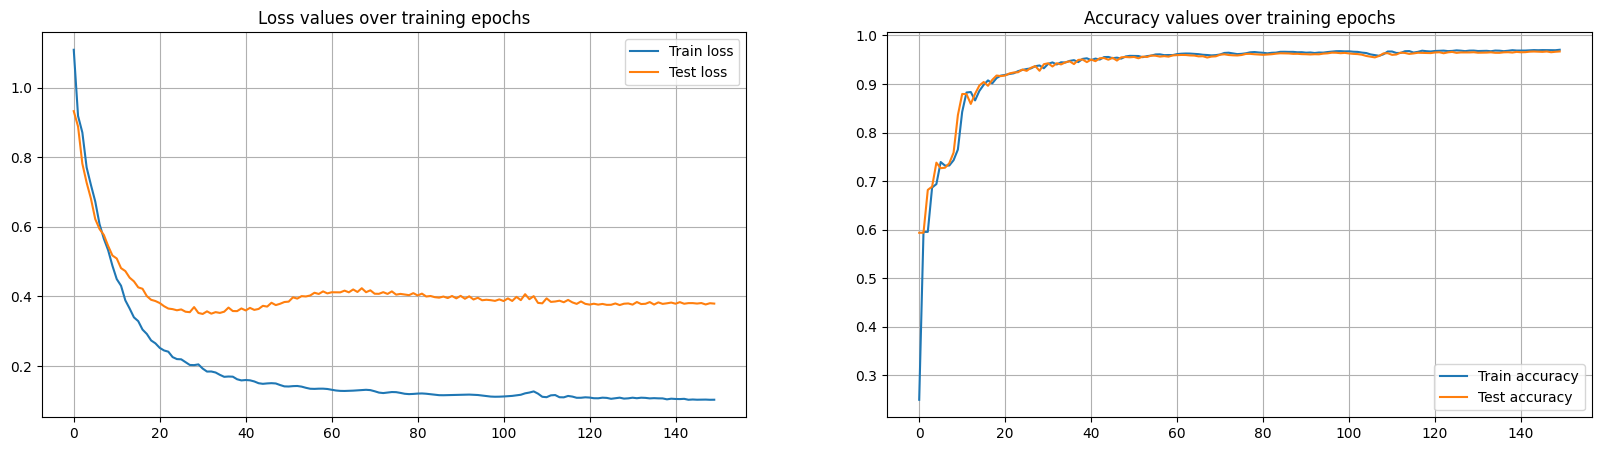

In [23]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range, train_losses, test_losses, train_acc, test_acc, figsize=(20, 5)
)

#### Analisando performance com diferentes hiperparâmetros

Para cada uma das duas opções de camadas, foram treinados 9 modelos, com diferentes _learning rates_ e diferentes números de unidades escondidas. Todos esses 18 modelos, no total, foram treinados em 150 épocas, (esse número de épocas foi obtido de forma empírica, após observação de quando os modelos tendiam a converter).

#### 2 Camadas

##### Learning rates com modelo `hidden_units=32`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.69          | 0.72                        | 0.69            | 0.72                          |
| 0.01          | 0.16          | 0.95                        | 0.16            | 0.95                          |
| 0.1           | 0.11          | 0.97                        | 0.12            | 0.97                          |

##### Learning rates com modelo `hidden_units=64`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.57          | 0.75                        | 0.57            | 0.77                          |
| 0.01          | 0.15          | 0.96                        | 0.15            | 0.96                          |
| 0.1           | 0.14          | 0.96                        | 0.14            | 0.96                          |

##### Learning rates com modelo `hidden_units=128`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.46          | 0.85                        | 0.45            | 0.85                          |
| 0.01          | 0.13          | 0.96                        | 0.13            | 0.96                          |
| 0.1           | 0.13          | 0.96                        | 0.13            | 0.96                          |

#### 3 Camadas

##### Learning rates com modelo `hidden_units=32`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.41          | 0.86                        | 0.41            | 0.86                          |
| 0.01          | 0.12          | 0.97                        | 0.12            | 0.97                          |
| 0.1           | 0.11          | 0.97                        | 0.12            | 0.97                          |

##### Learning rates com modelo `hidden_units=64`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.11          | 0.97                        | 0.13            | 0.96                          |
| 0.01          | 0.11          | 0.97                        | 0.12            | 0.97                          |
| 0.1           | 0.14          | 0.96                        | 0.15            | 0.96                          |

##### Learning rates com modelo `hidden_units=128`

| Learning Rate | Training loss | Training MulticlassAccuracy | Validation loss | Validation MulticlassAccuracy |
| ------------- | ------------- | --------------------------- | --------------- | ----------------------------- |
| 0.001         | 0.18          | 0.95                        | 0.18            | 0.95                          |
| 0.01          | 0.11          | 0.97                        | 0.13            | 0.96                          |
| 0.1           | 0.14          | 0.95                        | 0.13            | 0.96                          |

### Underfitting e Overfitting

Devido à distribuição dos dados, e à arquitetura do modelo, não foram obtidos em nenhum treinamento, discrepâncias entre os valores da função de perda dos dados de teste, assim como para os valores de acurácia entre os dois conjuntos. Isso leva à conclusão de que o modelo tem alta capacidade de generalização, com overfitting sendo muito improvável, mesmo após dezenas de milhares de épocas de treinamento.

Quanto a underfitting, a arquitetura já chega a valores altos de acurácia (~$0.9$), e baixos de perda (>$0.5$), com valores próximos a 150 épocas de forma geral a qualquer dos modelos treinados.


## Aplicando modelo em outro conjunto de dados


In [24]:
# Importando dados
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [25]:
# Normalizing data
X_train = X_train.reshape(60000, 784) / 255
X_test = X_test.reshape(10000, 784) / 255

In [26]:
# Instanciando novo modelo
mnist_model = ArtificialNeuralNetwork(
    in_features=784,
    num_classes=10,
    hidden_units=64,
    inner_layer=True,
).to(device)

In [27]:
# Instanciando função de perda
mnist_loss_fn = nn.CrossEntropyLoss()

# Instanciando otimizador
mnist_optimizer = Adam(
    params=mnist_model.parameters(),
    lr=0.01,
)

# Instanciando acurácia
mnist_acc = Accuracy('multiclass', num_classes=10).to(device)

# Definindo número de épocas
epochs = 100

In [28]:
# Transformando arrays em tensores
mnist_X_train = torch.from_numpy(X_train).type(torch.float32).to(device)
mnist_X_test = torch.from_numpy(X_test).type(torch.float32).to(device)
mnist_y_train = torch.from_numpy(y_train).type(torch.float32).to(device)
mnist_y_test = torch.from_numpy(y_test).type(torch.float32).to(device)

In [29]:
# Treinando modelo
mnist_history = training_loop(
    estimator=mnist_model,
    optimizer=mnist_optimizer,
    loss_fn=mnist_loss_fn,
    metric=mnist_acc,
    epochs=epochs,
    train_data=(mnist_X_train, mnist_y_train),
    validation_split=0.2,
    seed=42,
    print_every=10,
)

| Epoch: 1 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 2.31 | Training MulticlassAccuracy: 0.10 | Validation loss: 2.21 | Validation MulticlassAccuracy: 0.25 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 10 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.59 | Training MulticlassAccuracy: 0.82 | Validation loss: 0.57 | Validation MulticlassAccuracy: 0.82 |
-------------------------------------------------------------------------------------------------------------------------

| Epoch: 20 |
-------------------------------------------------------------------------------------------------------------------------
| Training loss: 0.38 | Training MulticlassAccuracy: 0.89 | Validation loss: 0.38 | Validation Multicla

#### Verificando previsões


In [30]:
# Obtendo previsões
with torch.inference_mode():
    mnist_model.eval()
    y_logits = mnist_model(mnist_X_test)
    y_preds = y_logits.argmax(dim=1).cpu()

y_true = mnist_y_test.cpu().numpy()

In [31]:
# Obtendo relatório de classificação
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.98       980
         1.0       0.98      0.98      0.98      1135
         2.0       0.96      0.97      0.96      1032
         3.0       0.94      0.96      0.95      1010
         4.0       0.96      0.96      0.96       982
         5.0       0.96      0.94      0.95       892
         6.0       0.97      0.97      0.97       958
         7.0       0.96      0.95      0.96      1028
         8.0       0.94      0.94      0.94       974
         9.0       0.95      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



#### Visualizando perda e acurácia


In [32]:
# Turning tensors into arrays
train_losses = torch.tensor(mnist_history['train_loss']).cpu().numpy()
test_losses = torch.tensor(mnist_history['val_loss']).cpu().numpy()
train_acc = torch.tensor(mnist_history['train_metric']).cpu().numpy()
test_acc = torch.tensor(mnist_history['val_metric']).cpu().numpy()

# Setting epoch range
epoch_range = [i for i in range(epochs)]

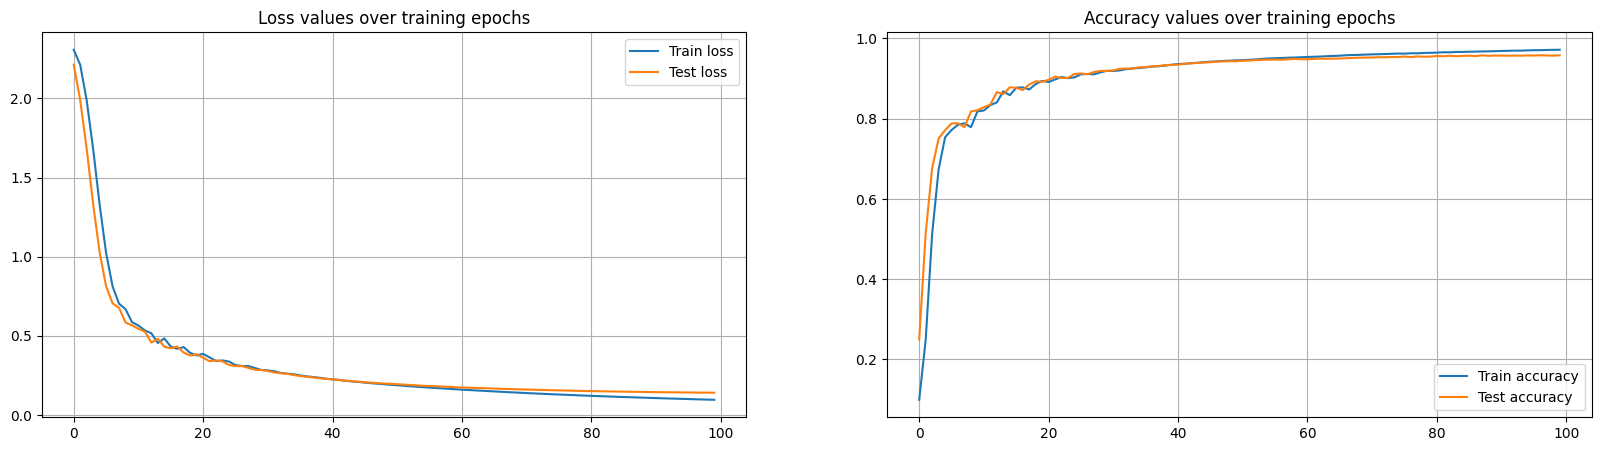

In [33]:
# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range, train_losses, test_losses, train_acc, test_acc, figsize=(20, 5)
)

## Rede neural from scratch


### Funções matemáticas


In [34]:
# ReLU activation function
def relu(Z):
    return np.maximum(0, Z)

In [35]:
# Derivative of ReLU
def d_relu_dx(Z):
    return Z > 0

In [36]:
# Softmax
def softmax(Z):
    return np.exp(Z) / np.sum(np.exp(Z), axis=0)

In [37]:
# Acurácia
def mnist_accuracy(y_pred, y_true) -> np.ndarray:
    return np.sum(y_pred == y_true) / y_true.size

### Codificação


In [38]:
# Função para codificação One-Hot
def one_hot(y: np.ndarray) -> np.ndarray:
    temp_y = y
    one_hot_y = np.zeros((temp_y.size, temp_y.max() + 1))
    one_hot_y[np.arange(temp_y.size), temp_y] = 1

    return one_hot_y.T

### Rede neural


In [39]:
# Neural net class
class MNISTtNeuralNet:
    def __init__(self, learning_rate: float) -> None:
        # Learning rate
        self.learning_rate = learning_rate

        # First layers weights and biases
        self.w_1 = np.random.rand(10, 784) - 0.5
        self.b_1 = np.random.rand(10, 1) - 0.5

        # Second layers weights and biases
        self.w_2 = np.random.rand(10, 10) - 0.5
        self.b_2 = np.random.rand(10, 1) - 0.5

    def __call__(self, *args, **kwds) -> None:
        return self.forward(*args, **kwds)

    def forward(self, x: np.ndarray) -> None:
        # First layer neurons output and activation
        self.z_1 = self.w_1.dot(x) + self.b_1
        self.a_1 = relu(self.z_1)

        # Second layer neurons output and activation
        self.z_2 = self.w_2.dot(self.a_1) + self.b_2
        self.a_2 = softmax(self.z_2)

In [40]:
def back_propagation(
    estimator: MNISTtNeuralNet,
    x: np.ndarray,
    y: np.ndarray,
) -> list[np.ndarray]:
    one_hot_y = one_hot(y)

    dz_2 = (1 / x.shape[1]) * (estimator.a_2 - one_hot_y)
    dw_2 = dz_2.dot(estimator.a_1.T)
    db_2 = np.sum(dz_2, axis=1).reshape(-1, 1)

    dz_1 = estimator.w_2.T.dot(dz_2) * d_relu_dx(estimator.z_1)
    dw_1 = dz_1.dot(x.T)
    db_1 = np.sum(dz_1, axis=1).reshape(-1, 1)

    estimator.w_1 -= estimator.learning_rate * dw_1
    estimator.b_1 -= estimator.learning_rate * db_1
    estimator.w_2 -= estimator.learning_rate * dw_2
    estimator.b_2 -= estimator.learning_rate * db_2

In [41]:
def compute_loss(y_preds: np.ndarray, y_true: np.ndarray) -> float:
    one_hot_y = one_hot(y_true)
    log_probs = np.log(y_preds + 1e-10)

    return -np.sum(one_hot_y * log_probs) / y_true.size

In [42]:
def train_mnist(
    estimator: MNISTtNeuralNet,
    epochs: int,
    train_data: Tuple[np.ndarray, np.ndarray],
    validation_split: float | None = None,
    seed: int = None,
    print_every: int = 1,
) -> Dict[str, List[float]]:

    if seed is not None:
        torch.manual_seed(seed)

    X_train, y_train = train_data
    if validation_split is not None:
        X_train, X_val, y_train, y_val = train_test_split(
            X_train,
            y_train,
            test_size=validation_split,
            random_state=seed,
        )
        X_val = X_val.T
    X_train = X_train.T

    data_tracking = {
        'train_loss': [],
        'train_metric': [],
        'val_loss': [],
        'val_metric': [],
    }

    validation_print = ''
    val_metric_print = ''

    for epoch in range(epochs):
        estimator(X_train)
        train_preds = np.argmax(estimator.a_2, 0)

        training_loss = compute_loss(estimator.a_2, y_train)
        data_tracking['train_loss'].append(training_loss)

        training_metric = mnist_accuracy(y_pred=train_preds, y_true=y_train)
        data_tracking['train_metric'].append(training_metric)

        back_propagation(estimator=estimator, x=X_train, y=y_train)
        if validation_split is not None:
            estimator(X_val)
            val_preds = np.argmax(estimator.a_2, 0)
            validation_loss = compute_loss(val_preds, y_val)
            data_tracking['val_loss'].append(validation_loss)

            validation_metric = mnist_accuracy(val_preds, y_val)
            data_tracking['val_metric'].append(validation_metric)

            val_metric_print = f' Validation accuracy: {validation_metric:.2f} |'

            validation_print = f' Validation loss: {validation_loss:.2f} |'

        train_metric_print = f' Training accuracy: {training_metric:.2f} |'

        if (epoch + 1) % print_every == 0 or epoch == 0:
            print(
                f'| Epoch: {epoch + 1} |',
                '-' * 101,
                f'| Training loss: {training_loss:.2f} |'
                + train_metric_print
                + validation_print
                + val_metric_print,
                '-' * 101,
                sep='\n',
                end='\n\n',
            )

    return data_tracking

In [43]:
def test_prediction(
    estimator: MNISTtNeuralNet,
    data: Tuple[np.ndarray, np.ndarray],
) -> None:
    x, y = data

    index = np.random.randint(1, x.shape[1])
    current_image = x[:, index, None]

    estimator(x[:, index, None])
    prediction = np.argmax(estimator.a_2, 0)

    label = y[index]

    print('Prediction: ', prediction.item())
    print('Label:      ', label)

    current_image = current_image.reshape(28, 28)
    plt.imshow(current_image, cmap='gray')
    plt.axis('off')
    plt.show()

In [44]:
# Instantiating class
neural_net = MNISTtNeuralNet(learning_rate=0.2)

# Training model
mnist_history = train_mnist(
    estimator=neural_net,
    epochs=1000,
    train_data=(X_train, y_train),
    validation_split=0.2,
    print_every=100,
)

| Epoch: 1 |
-----------------------------------------------------------------------------------------------------
| Training loss: 4.17 | Training accuracy: 0.12 | Validation loss: 3.48 | Validation accuracy: 0.15 |
-----------------------------------------------------------------------------------------------------

| Epoch: 100 |
-----------------------------------------------------------------------------------------------------
| Training loss: 0.77 | Training accuracy: 0.75 | Validation loss: 1.21 | Validation accuracy: 0.74 |
-----------------------------------------------------------------------------------------------------

| Epoch: 200 |
-----------------------------------------------------------------------------------------------------
| Training loss: 0.54 | Training accuracy: 0.84 | Validation loss: 1.05 | Validation accuracy: 0.83 |
-----------------------------------------------------------------------------------------------------

| Epoch: 300 |
---------------------

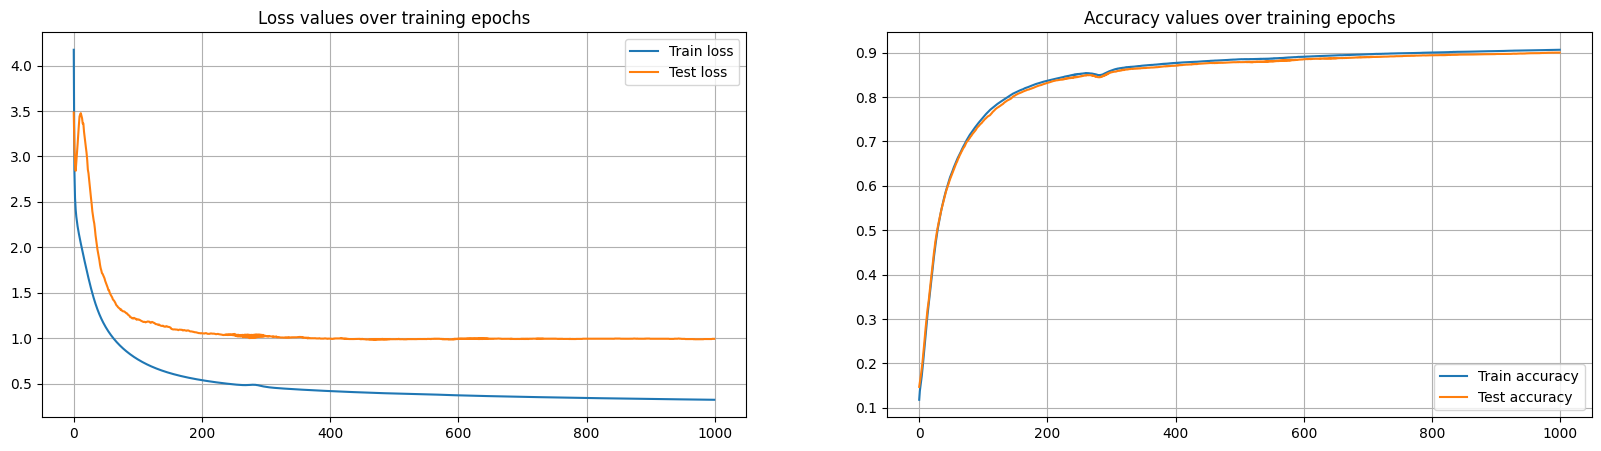

In [45]:
# Setting epoch range
epoch_range = [i for i in range(1000)]

# Imprimindo gráficos de perda e acurácia
plot_loss_acc(
    epoch_range,
    train_losses=mnist_history['train_loss'],
    test_losses=mnist_history['val_loss'],
    train_acc=mnist_history['train_metric'],
    test_acc=mnist_history['val_metric'],
    figsize=(20, 5),
)

Prediction:  8
Label:       8


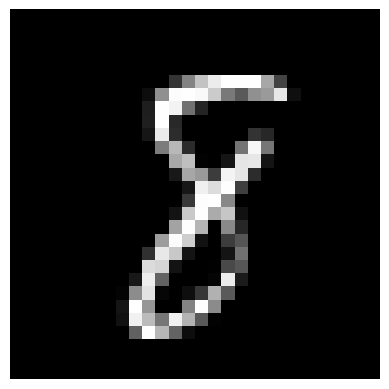

In [46]:
# Visualizando previsões
test_prediction(estimator=neural_net, data=(X_test.T, y_test))